# Hyperbolicity of neural representations

In this example, we empirically compute the delta value (hyperbolicity) of neural representations generated from different tuning curves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Tuning curve function class

We define different tuning curves based on their place field size distributions.
We select the following distributions.
For fair comparison, we select their parameters so their means are the same.

#### **Exponential**

$$
X \sim \mathrm{Exp}(\lambda=1), \quad f_X(x) =
\begin{cases}
e^{-x}, & x \ge 0 \\
0, & x < 0
\end{cases},
\quad
\mathbb{E}[X] = 1.
$$

#### **Log-normal**

$$
X \sim \mathrm{LogNormal}(\mu=-0.5,\sigma=1),
\quad
f_X(x)=
\frac{1}{x\sqrt{2\pi}}
\exp\!\left(
-\frac{(\ln x + 0.5)^2}{2}
\right),
\qquad x>0
,
\quad
\mathbb{E}[X]
=
e^{\mu+\sigma^2/2}
=
1.
$$

#### **Uniform**

$$
X \sim \mathrm{Uniform}(0.2,1.8),
\quad
f_X(x)=
\begin{cases}
\frac{1}{1.6}, & 0.2 \le x \le 1.8 \\
0, & \text{otherwise}
\end{cases}
,
\quad
\mathbb{E}[X]
=
\frac{0.2+1.8}{2}
=
1.
$$

#### **Constant**

$$
X = 1,
\quad f_X(x)=\delta(x-1),
$$
where $\delta$ denotes the Dirac delta distribution.

#### **Half-normal**

$$
X \sim \mathrm{HalfNormal}\!\left(\sigma=\sqrt{\frac{\pi}{2}}\right),
\quad
f_X(x)
=
\sqrt{\frac{2}{\pi\sigma^2}}
\exp\!\left(
-\frac{x^2}{2\sigma^2}
\right),
\qquad x \ge 0
,\quad
\sigma=\sqrt{\frac{\pi}{2}},
\quad
\mathbb{E}[X]
=
\sigma\sqrt{\frac{2}{\pi}}
=
1.
$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def draw_widths(name, N, beta, rng):
    """Return an array of N positive widths under the named distribution.

    beta sets the location/scale of the distribution. For the exponential
    case, beta is the distribution's mean; for the others it is the analogous
    scale parameter so that all distributions can be compared on equal footing.

    To recover the regime where place-field size scales with environment size,
    pass beta proportional to L. To recover the fixed-receptive-field regime,
    pass beta constant.
    """
    if name == "exponential":
        return rng.exponential(scale=beta, size=N)

    if name == "uniform":
        # Bounded above by 2*beta. D.2.1 predicts delta -> infty.
        return rng.uniform(0.1 * beta, 2.0 * beta, size=N)

    if name == "constant":
        return np.full(N, beta)

    if name == "lognormal":
        # mean of LN(mu, s) is exp(mu + s^2/2). Pick mu so mean = beta.
        s = 1.0
        mu = np.log(beta) - 0.5 * s ** 2
        return rng.lognormal(mean=mu, sigma=s, size=N)

    if name == "half_normal":
        # E[|N(0, beta^2)|] = beta * sqrt(2/pi). Rescale so mean ~ beta.
        return np.abs(rng.normal(0.0, beta * np.sqrt(np.pi / 2.0), size=N))

    raise ValueError(f"unknown distribution: {name}")



Here we define the semi-metric used in the paper and the hyperbolicity helper function

In [12]:

# ---------- Semi-metric ----------

def population_response(s, centers, widths):
    """lambda_i(s) = exp(-||s - c_i||^2 / (2 sigma_i^2)), shape (N,)."""
    # s: (D,), centers: (N, D), widths: (N,)
    diff2 = np.sum((centers - s) ** 2, axis=1)
    return np.exp(-diff2 / (2.0 * widths ** 2))


def semi_metric(s_a, s_b, centers, widths, eps=1e-300):
    """d(s_a, s_b) = -log <lambda(s_a), lambda(s_b)>."""
    la = population_response(s_a, centers, widths)
    lb = population_response(s_b, centers, widths)
    K = np.dot(la, lb)
    return -np.log(max(K, eps))


# ---------- Gromov 4-point excess ----------

def gromov_excess(d01, d23, d02, d13, d03, d12):
    """Delta = (largest pair-sum - second-largest) / 2."""
    sums = np.sort([d01 + d23, d02 + d13, d03 + d12])
    return (sums[2] - sums[1]) / 2.0


def sample_delta(L, D, N, beta, dist_name, n_quadruples, rng):
    """Draw one realization of (widths, centers), then sample n_quadruples 4-tuples
    and return the array of Delta values.

    Vectorized: for each quadruple we compute the (4, N) matrix of population
    responses once and read all 6 pair-inner-products from it.
    """
    widths = draw_widths(dist_name, N, beta, rng)
    centers = rng.uniform(0.0, L, size=(N, D))  # (N, D)
    two_sigma2 = 2.0 * widths ** 2              # (N,)

    deltas = np.empty(n_quadruples)
    eps = 1e-300
    for k in range(n_quadruples):
        pts = rng.uniform(0.0, L, size=(4, D))                          # (4, D)
        # Squared distances from each point to each center: (4, N)
        diff2 = ((pts[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        # Population responses lambda(s_i) for i=0..3: (4, N)
        Lambda = np.exp(-diff2 / two_sigma2[None, :])
        # 6 inner products in one shot:
        K01 = Lambda[0] @ Lambda[1]
        K23 = Lambda[2] @ Lambda[3]
        K02 = Lambda[0] @ Lambda[2]
        K13 = Lambda[1] @ Lambda[3]
        K03 = Lambda[0] @ Lambda[3]
        K12 = Lambda[1] @ Lambda[2]
        # Semi-metric distances
        d01 = -np.log(max(K01, eps))
        d23 = -np.log(max(K23, eps))
        d02 = -np.log(max(K02, eps))
        d13 = -np.log(max(K13, eps))
        d03 = -np.log(max(K03, eps))
        d12 = -np.log(max(K12, eps))
        deltas[k] = gromov_excess(d01, d23, d02, d13, d03, d12)

    return deltas

#### Simulation setup

We follow our Theorem 4.2 and see what type of tuning curves will induce statistically hyperbolic semi-metric space.
Specifically, we will empirically compute the 4-point condition over a large number of samples.
Next, we will report the 95th percentile of the empirical $\delta$.


In [16]:

# ---------- Experiment driver ----------

def run_experiment(beta_scaling="1"):

    D = 2
    L_values = np.array([2.0, 4.0, 6.0, 8.0, 12.0, 16.0, 20.0])
    distributions = ["exponential", "uniform", "constant", "lognormal", "half_normal"]
    n_quadruples = 1500

    def beta_of_L(L):
        if beta_scaling == "1":
            return 1.0
        if beta_scaling == "0.5":
            return 0.5
        raise ValueError(beta_scaling)

    def N_of_L(L, beta):
        return min(8000, max(100, int(20 * (L / beta) ** D)))

    results = {dist: {"L": [], "N": [], "beta": [], "p50": [], "p95": [], "p99": []}
               for dist in distributions}

    for dist in distributions:
        print(f"\n=== {dist}  (beta_scaling={beta_scaling}) ===")
        for L in L_values:
            beta = beta_of_L(L)
            N = N_of_L(L, beta)
            deltas = sample_delta(
                L=L, D=D, N=N, beta=beta, dist_name=dist,
                n_quadruples=n_quadruples, rng=rng,
            )
            p50 = np.percentile(deltas, 50)
            p95 = np.percentile(deltas, 95)
            p99 = np.percentile(deltas, 99)
            results[dist]["L"].append(float(L))
            results[dist]["N"].append(int(N))
            results[dist]["beta"].append(float(beta))
            results[dist]["p50"].append(float(p50))
            results[dist]["p95"].append(float(p95))
            results[dist]["p99"].append(float(p99))
            print(f"  L={L:5.1f}  beta={beta:5.2f}  N={N:6d}  "
                  f"median={p50:7.3f}  p95={p95:7.3f}  p99={p99:7.3f}")

    return results, L_values


# ---------- Plotting ----------

def plot_results(results_1, results_2, L_values):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    colors = {
        "exponential": "#d62728",
        "uniform":     "#1f77b4",
        "constant":    "#2ca02c",
        "lognormal":   "#9467bd",
        "half_normal": "#ff7f0e",
    }
    markers = {
        "exponential": "o",
        "uniform":     "s",
        "constant":    "^",
        "lognormal":   "D",
        "half_normal": "v",
    }
    labels = {
        "exponential": r"Exponential (Theorem 4.1)",
        "uniform":     r"Uniform",
        "constant":    r"Constant",
        "lognormal":   r"Log-normal",
        "half_normal": r"Half-normal",
    }

    panels = [
        (axes[0], results_1,  r"$\beta = 1$"),
        (axes[1], results_2, r"$\beta = 0.5$"),
    ]

    for ax, results, title in panels:
        for dist, data in results.items():
            ax.plot(
                data["L"], data["p95"],
                marker=markers[dist], color=colors[dist],
                label=labels[dist], linewidth=2, markersize=7,
            )
        ax.set_xlabel(r"Environment size $L$")
        ax.set_ylabel(r"$\delta \approx$ 95th-pctl of $\Delta$")
        ax.set_title(title)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(
        r"Gromov 4-point hyperbolicity $\delta$ vs. environment size $L$, with $N = O((L/\beta)^D)$",
        fontsize=12, y=1.02,
    )
    fig.tight_layout()
    plt.show()


**Lets run the code!**

You should expect to see that both the exponential distribution and the log-normal distribution have their hyperbolicity constant $\delta$ stay low even when the environment size grows.

Other distributions of place field sizes have stronger scaling of $\delta$ in the size of the environment.


Regime 1: beta = 1

=== exponential  (beta_scaling=1) ===
  L=  2.0  beta= 1.00  N=   100  median=  0.015  p95=  0.069  p99=  0.092
  L=  4.0  beta= 1.00  N=   320  median=  0.024  p95=  0.094  p99=  0.125
  L=  6.0  beta= 1.00  N=   720  median=  0.050  p95=  0.177  p99=  0.241
  L=  8.0  beta= 1.00  N=  1280  median=  0.062  p95=  0.251  p99=  0.326
  L= 12.0  beta= 1.00  N=  2880  median=  0.102  p95=  0.379  p99=  0.515
  L= 16.0  beta= 1.00  N=  5120  median=  0.146  p95=  0.536  p99=  0.729
  L= 20.0  beta= 1.00  N=  8000  median=  0.152  p95=  0.615  p99=  0.785

=== uniform  (beta_scaling=1) ===
  L=  2.0  beta= 1.00  N=   100  median=  0.011  p95=  0.045  p99=  0.062
  L=  4.0  beta= 1.00  N=   320  median=  0.056  p95=  0.221  p99=  0.309
  L=  6.0  beta= 1.00  N=   720  median=  0.142  p95=  0.539  p99=  0.809
  L=  8.0  beta= 1.00  N=  1280  median=  0.234  p95=  0.901  p99=  1.320
  L= 12.0  beta= 1.00  N=  2880  median=  0.545  p95=  2.284  p99=  3.201
  L= 16.0  beta= 1

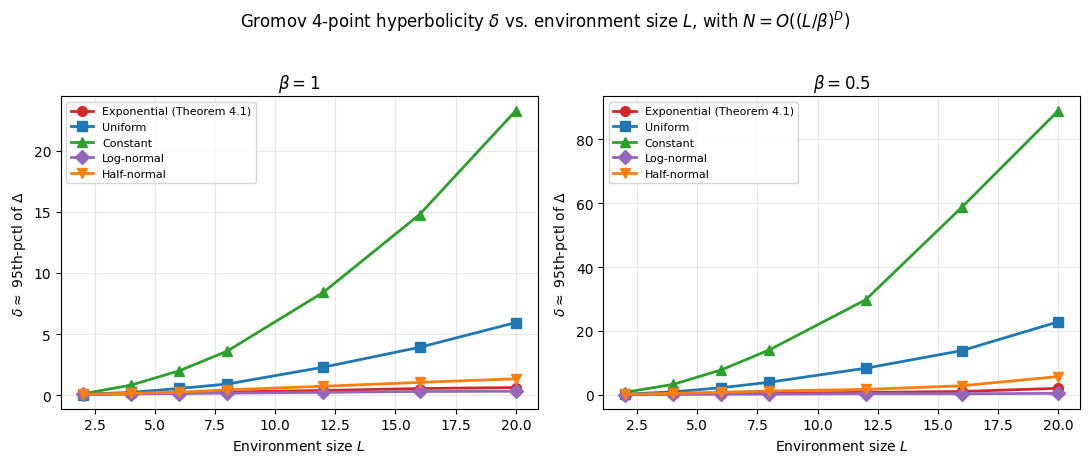

In [20]:

print("\n" + "=" * 60)
print("Regime 1: beta = 1")
print("=" * 60)
results_fixed, L_values = run_experiment(beta_scaling="1")

print("\n" + "=" * 60)
print("Regime 2: beta = 0.5")
print("=" * 60)
results_with_L, _ = run_experiment(beta_scaling="0.5")

plot_results(results_fixed, results_with_L, L_values)

import json
out = {
    "fixed_beta": {dist: {k: ([float(x) for x in v] if isinstance(v, list) else v)
                          for k, v in data.items()}
                    for dist, data in results_fixed.items()},
    "beta_scales_with_L": {dist: {k: ([float(x) for x in v] if isinstance(v, list) else v)
                                    for k, v in data.items()}
                            for dist, data in results_with_L.items()},
}